# Pandas for Data Preprocessing — A Complete Hands-On Lab

**Pandas** is Python's most widely-used library for data manipulation and analysis. The name comes from **"Panel Data"** — a term from econometrics for datasets that track multiple entities over time — combined with **"Python Data Analysis."**

In this lab, you'll use Pandas (together with a little help from `scikit-learn`) to take a **raw, messy dataset and prepare it for machine learning** — exactly the workflow a data analyst or ML engineer runs before training any model.

### The Dataset

Throughout this lab we'll work with `loan_small.csv` — a small bank loan-application dataset. Each row is one applicant, with columns like:

| Column | Meaning |
|---|---|
| `Loan_ID` | Unique identifier for the application |
| `Gender` | Applicant's gender |
| `ApplicantIncome` | Applicant's monthly income |
| `CoapplicantIncome` | Co-applicant's monthly income (0 if none) |
| `LoanAmount` | Requested loan amount |
| `Area` | Property area: Urban / Semiurban / Rural |
| `Loan_Status` | Whether the loan was approved (`Y`) or not (`N`) |

This is a realistic, if small, slice of the kind of data a bank would use to decide whether to approve a loan — and it has the two problems **every** real dataset has: missing values and non-numeric columns.

### What You'll Learn

1. **Basic Operations** — loading, previewing, and slicing a DataFrame
2. **Handling Missing Values** — finding and fixing gaps in your data
3. **Encoding Techniques** — turning categories like `"Urban"` into numbers a model can use
4. **Data Normalization** — putting numeric columns on a comparable scale
5. **Data Splitting** — dividing data into training and test sets

> **Note:** This notebook is written for you to **run yourself**, cell by cell, alongside `loan_small.csv`. The code has been checked for correctness, but no cells have been pre-executed — run each cell in order so the variables build up correctly.

### The Big Picture — A Typical Preprocessing Pipeline

Before diving into code, here's the pipeline this entire lab builds, step by step. Run the cell below to see it.

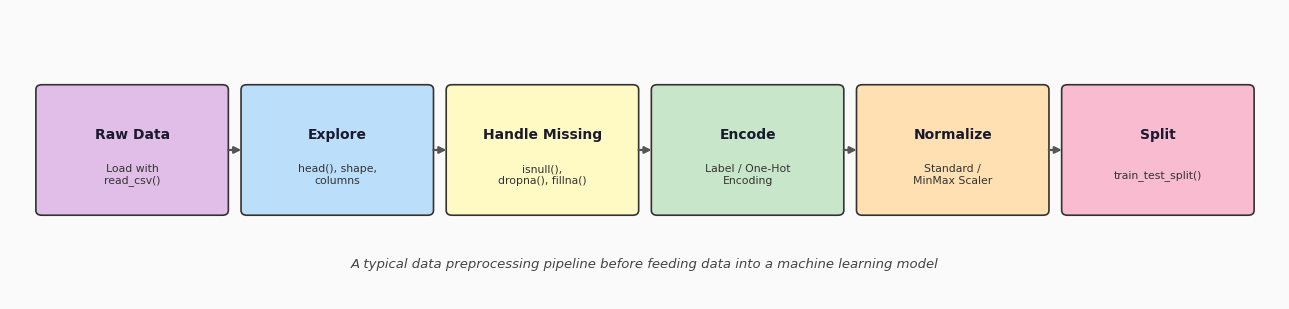

Each colored box above is one section of this lab. By the end, you'll have taken `loan_small.csv` all the way from a raw CSV file to clean, numeric, split `X_train` / `X_test` / `Y_train` / `Y_test` arrays — ready to feed into any scikit-learn model.

---

## Setup

If Pandas isn't already installed in your environment, running it will raise `ModuleNotFoundError: No module named 'pandas'`. The cell below installs it — safe to run even if it's already installed (it will just confirm the existing version).

In [10]:
!pip install pandas

In [11]:
# Import libraries
import pandas as pd

---
## Section 1: Basic Operations

Once you've loaded a dataset with Pandas, it's stored as a **DataFrame** — think of it as a spreadsheet or SQL table living in memory, with labeled rows and columns. Here's how to load one and start exploring it.

In [12]:
# Read data from the csv file
dataset = pd.read_csv('/content/loan_small.csv')

`pd.read_csv()` reads a CSV file from disk and returns it as a DataFrame. Make sure `loan_small.csv` is in the **same folder** as this notebook (or provide the full file path), otherwise you'll get a `FileNotFoundError`.

In [13]:
#look at the all values
dataset

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,LP001002,NaN,5849.0,0.0,NaN,urban,Y
1,LP001003,Male,4583.0,NaN,128.0,semi,N
2,LP001005,Male,3000.0,0.0,66.0,NaN,Y
3,LP001006,Female,2583.0,2358.0,120.0,semi,NaN
4,LP001008,Male,NaN,0.0,141.0,urban,Y
5,LP001011,Male,5417.0,4196.0,267.0,semi,Y
6,LP001013,Male,2333.0,1516.0,NaN,rural,Y
7,LP001014,Female,3036.0,2504.0,158.0,semi,N
8,LP001018,Male,4006.0,1526.0,168.0,rural,Y
9,LP001020,Male,12841.0,10968.0,349.0,semi,N


Simply typing the DataFrame's name displays it. For small datasets like this one (15 rows) that's fine — but for a dataset with thousands or millions of rows, printing everything is slow and unreadable. That's where `.head()` comes in.

In [14]:
#Look at the first 5 values
dataset.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,LP001002,NaN,5849.0,0.0,NaN,urban,Y
1,LP001003,Male,4583.0,NaN,128.0,semi,N
2,LP001005,Male,3000.0,0.0,66.0,NaN,Y
3,LP001006,Female,2583.0,2358.0,120.0,semi,NaN
4,LP001008,Male,NaN,0.0,141.0,urban,Y


**`dataset.head()`** displays the first 5 rows of a DataFrame by default, letting you quickly preview the data structure, column names, and sample values — the very first thing any data analyst does with a new dataset.

> 💡 **Tip:** `dataset.head(10)` shows the first 10 rows instead of 5. There's also `dataset.tail()` for the last rows.

### Selecting Rows and Columns with `.iloc`

`.iloc` accesses data by **integer position** — the same 0-indexed system as Python lists. This is useful when you want a specific slice of rows and columns without typing out column names.

**Real-world scenario:** Imagine you're a loan officer who only wants a quick look at the second and third columns (whatever they happen to be) for the first three applicants — without needing to know their exact names yet.

In [15]:
# Access the data using iloc.
# Example - Get first three rows from the second and third column
subset = dataset.iloc[0:3, 1:3]

**Explanation:**

- `dataset.iloc[0:3, 1:3]` selects **rows 0 to 2** (the first three rows) and **columns 1 to 2** (the second and third columns).
- Just like regular Python slicing, both ranges are **exclusive of the end value** — `0:3` means rows 0, 1, 2 (not row 3), and `1:3` means columns 1, 2 (not column 3).
- The result is stored in a new variable, `subset`, leaving the original `dataset` untouched.

In [16]:
subset

,Gender,ApplicantIncome
0,NaN,5849.0
1,Male,4583.0
2,Male,3000.0


### Selecting Columns by Name

Most of the time, you'll want columns by their **name**, not their position — it's more readable and doesn't break if column order changes.

**Real-world scenario:** Suppose you want to study whether `Gender` correlates with `ApplicantIncome`. You don't need every column — just these two.

In [17]:
# Access the data using column names
# Get all rows of the column Gender and ApplicantIncome
subsetN = dataset[['Gender', 'ApplicantIncome']]

**Explanation:**

- `dataset[['Gender', 'ApplicantIncome']]` selects **all rows** for the columns named `"Gender"` and `"ApplicantIncome"`.
- Notice the **double square brackets**: the outer `[ ]` is the selection syntax, the inner `[ ]` is a Python list of column names. Using a list (even for one column) always returns a DataFrame; a single string like `dataset['Gender']` returns a 1-D **Series** instead.
- `subsetN` stores the resulting subset — a smaller DataFrame with only the two requested columns, but still all 15 rows.

In [18]:
subsetN

,Gender,ApplicantIncome
0,NaN,5849.0
1,Male,4583.0
2,Male,3000.0
3,Female,2583.0
4,Male,NaN
5,Male,5417.0
6,Male,2333.0
7,Female,3036.0
8,Male,4006.0
9,Male,12841.0


You can also **combine** name-based column selection with row slicing — for example, to get just the first three applicants' Gender and Income.

In [19]:
# Get first three rows of the columns Gender and ApplicantIncome
subsetN = dataset[['Gender', 'ApplicantIncome']][0:3]

In [20]:
subsetN

,Gender,ApplicantIncome
0,NaN,5849.0
1,Male,4583.0
2,Male,3000.0


### Checking the Shape and Columns

Before doing any real analysis, it's good practice to check **how big** your dataset is and **what columns** it has.

In [21]:
# Get the Shape of the dataframe (Row x Columns)
dataset.shape

(16, 7)

`.shape` returns a tuple `(rows, columns)`. For `loan_small.csv` this should show `(15, 7)` — 15 applicants, 7 columns. Checking shape is a quick sanity check: if you expected 1,000 rows and see `(12, 7)`, something went wrong with your file path or loading step.

In [22]:
# Get column names of the dataframe
dataset.columns

Index(['Loan_ID', 'Gender', 'ApplicantIncome', 'CoapplicantIncome',
       'LoanAmount', 'Area', 'Loan_Status'],
      dtype='object')

In [23]:
# Get column names of the dataframe
dataset.columns.to_list()

['Loan_ID',
 'Gender',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Area',
 'Loan_Status']

Both lines above return the column names, but in slightly different forms:

- `dataset.columns` returns a special Pandas **`Index`** object — good for quick viewing.
- `dataset.columns.to_list()` converts that into a plain **Python list** — easier to loop over, slice, or pass into other functions (like the `cols` lists you'll build in the next section).

---

## Section 2: Handling Missing Values

Real-world data is almost never complete. An applicant might have left the `LoanAmount` field blank, or a form might not have recorded `Gender`. Handling missing values properly is a **crucial** step — a model trained on data with silent, unhandled gaps can produce misleading predictions, and many scikit-learn algorithms will simply throw an error if they encounter a `NaN`.

Below are the most common ways to find and fix missing values.

In [24]:
# Find out columns with missing values
dataset.isnull()
# it will project 'True' where there is a missing value, can make things difficult to read via naked eyes

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,False,True,False,False,True,False,False
1,False,False,False,True,False,False,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,False,True
4,False,False,True,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,True,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


`.isnull()` returns a DataFrame the **same shape** as your original data, but filled with `True`/`False` — `True` wherever a value is missing. It's precise, but for anything beyond a handful of rows, scanning a grid of `True`/`False` by eye is impractical. That's why we usually summarize it instead.

In [25]:
# Here, we will find missing values count for each column
dataset.isnull().sum(axis=0)

,0
Loan_ID,0
Gender,1
ApplicantIncome,2
CoapplicantIncome,1
LoanAmount,3
Area,1
Loan_Status,1


Chaining `.sum(axis=0)` after `.isnull()` adds up the `True` values (which Python treats as `1`) **down each column**, giving you a clean count of missing values per column. This is usually the very first check a data analyst runs on a new dataset — it immediately tells you *where* the problems are. For example, if `LoanAmount` shows 2 missing out of 15 rows, that's over 13% of a financially critical column gone — worth knowing before you calculate anything from it.

### Option 1: Drop Rows with Missing Values

The simplest fix is to remove rows that have gaps. You can do this narrowly (only care about specific columns) or broadly (any missing value anywhere).

In [26]:
# Drop missing values from a particular row say for e.g. LoanAmount and Area
dataset_clean = dataset.dropna(subset=['LoanAmount', 'Area'])

`dropna(subset=['LoanAmount', 'Area'])` drops a row **only if** it has a missing value in `LoanAmount` **or** `Area` — missing values in other columns (like `Gender`) are ignored by this call. This is the more surgical option: you only lose rows where the columns you actually care about are incomplete.

In [27]:
dataset_clean.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
1,LP001003,Male,4583.0,NaN,128.0,semi,N
3,LP001006,Female,2583.0,2358.0,120.0,semi,NaN
4,LP001008,Male,NaN,0.0,141.0,urban,Y
5,LP001011,Male,5417.0,4196.0,267.0,semi,Y
7,LP001014,Female,3036.0,2504.0,158.0,semi,N


In [28]:
# Drop all the rows with missing values
dataset_clean_full = dataset.dropna()

`dataset.dropna()` with no arguments drops a row if **any** column has a missing value — the most aggressive option. Notice this is stored in a **new variable**, `dataset_clean_full`, rather than overwriting `dataset_clean` from the previous step. Keeping them separate avoids a common source of bugs: silently overwriting a variable means any code below that expects the *first* cleaned version will get the *second* one instead. We'll reuse `dataset_clean_full` later in Section 4.

> ⚠️ **Trade-off:** Dropping rows is easy, but it throws away data — and if many columns have scattered missing values, `dropna()` with no arguments can eliminate a large fraction of your dataset. Filling in missing values (below) is often the better choice when you can't afford to lose rows.

In [29]:
dataset_clean_full.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
5,LP001011,Male,5417.0,4196.0,267.0,semi,Y
7,LP001014,Female,3036.0,2504.0,158.0,semi,N
8,LP001018,Male,4006.0,1526.0,168.0,rural,Y
9,LP001020,Male,12841.0,10968.0,349.0,semi,N
10,LP001024,Female,3200.0,700.0,70.0,urban,Y


### Option 2: Fill Missing Values

Instead of dropping incomplete rows, you can **fill** the gaps with a sensible substitute — the column's most common value for categories, or its average for numbers. First, let's work on a **copy** of the dataset so the original stays untouched.

In [30]:
#Create a duplicate of existing dataset
dt = dataset.copy()

`.copy()` creates an **independent** copy of the DataFrame. Without it, `dt = dataset` would just create a second name pointing at the *same* underlying data — modifying `dt` would silently modify `dataset` too (and can trigger Pandas' `SettingWithCopyWarning`). Always `.copy()` before making destructive changes if you still need the original.

In [31]:
dt.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,LP001002,NaN,5849.0,0.0,NaN,urban,Y
1,LP001003,Male,4583.0,NaN,128.0,semi,N
2,LP001005,Male,3000.0,0.0,66.0,NaN,Y
3,LP001006,Female,2583.0,2358.0,120.0,semi,NaN
4,LP001008,Male,NaN,0.0,141.0,urban,Y


In [32]:
# Replace missing categorical values using column names

#Step1: Create a list of categorical columns
cols = ['Gender', 'Area', 'Loan_Status']

#Step2: fillna for filling NaN values using mode (i.e. the most frequently occurring category)
dt[cols] = dt[cols].fillna(dt.mode().iloc[0])

#Step3: Check that there are no missing values left in these columns
dt[cols].isnull().sum()

,0
Gender,0
Area,0
Loan_Status,0


**Explanation:**

- `dt.mode()` computes the **mode** (most frequent value) of every column; `.iloc[0]` grabs the first row of that result, giving one representative value per column.
- `dt[cols] = dt[cols].fillna(...)` fills any `NaN` in each of the three categorical columns with that column's mode — e.g. if `"Urban"` is the most common `Area`, missing `Area` values become `"Urban"`.
- The final line re-runs `.isnull().sum()` on just these columns as a **sanity check** — it should now print `0` for all three.

In [33]:
# Replace missing numerical values using column names

#Step1: Create a list of numerical columns
cols2 = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

#Step2: fillna for filling NaN values using the mean (average) of each column
dt[cols2] = dt[cols2].fillna(dt[cols2].mean())

#Step3: Check that there are no missing values left in these columns
dt[cols2].isnull().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0


**Explanation:**

- For **numerical** columns, filling with the **mode** (like we did for categories) doesn't make as much sense — instead we use the **mean** (average), which is a reasonable "typical" value.
- `dt[cols2].mean()` computes the mean of each numeric column; `fillna(...)` replaces missing entries with their respective column mean.

> 💡 **Going further:** The mean is sensitive to outliers — a single applicant with an extremely high income can pull the average up. For skewed numerical data, filling with the **median** (`dt[cols2].median()`) is often a more robust choice.

---

## Section 3: Encoding Techniques

Machine learning algorithms work with **numbers**, not text. Columns like `Gender` (`"Male"`/`"Female"`) or `Area` (`"Urban"`/`"Rural"`/`"Semiurban"`) need to be converted into numeric form before they can be fed into a model. This process is called **encoding**, and there are two common approaches, each suited to a different kind of category.

### Type 1: Label Encoding

**Label encoding** assigns a unique integer to each category (e.g. `Rural → 0`, `Semiurban → 1`, `Urban → 2`). It's simple and memory-efficient, but it has an important catch: it implicitly tells the model that `2 > 1 > 0` — that there's an **order** between categories. This is exactly right for genuinely **ordinal** data (like `Low < Medium < High`), but misleading for **nominal** data with no natural order (like `Area`, where "Urban" isn't inherently "greater than" "Rural").

In [34]:
# Get datatypes of all the columns of the dataframe
dt.dtypes

,0
Loan_ID,object
Gender,object
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Area,object
Loan_Status,object


`.dtypes` shows the data type Pandas has inferred for each column. Text columns like `Gender`, `Area`, and `Loan_Status` show up as `object` — Pandas' generic type for strings. We need to convert these to numeric types before encoding.

In [35]:
# Convert string/object column types to categorical
dt[cols] = dt[cols].astype('category')

Converting to the `'category'` dtype tells Pandas to treat these as a fixed set of categories internally, which makes the next step (`.cat.codes`) possible — and is also more memory-efficient than storing repeated strings.

In [36]:
dt[cols].dtypes

,0
Gender,category
Area,category
Loan_Status,category


In [37]:
# Convert string to numerical codes
for columns in cols:
    dt[columns] = dt[columns].cat.codes

`.cat.codes` replaces each category with an integer code, assigned alphabetically by default (e.g. for `Area`: `Rural → 0`, `Semiurban → 1`, `Urban → 2`). The loop applies this to all three categorical columns (`Gender`, `Area`, `Loan_Status`) at once.

In [38]:
dt.dtypes    #see columns like Gender, Area and Loan_Status now showing as int8 type

,0
Loan_ID,object
Gender,int8
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Area,int8
Loan_Status,int8


In [39]:
dt.head()   ##columns like Gender, Area and Loan_Status now show integer values for categories: 0, 1, 2 and so on

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,LP001002,1,5849.000000,0.000000,140.923077,2,1
1,LP001003,1,4583.000000,2509.333333,128.000000,1,0
2,LP001005,1,3000.000000,0.000000,66.000000,1,1
3,LP001006,0,2583.000000,2358.000000,120.000000,1,1
4,LP001008,1,4103.571429,0.000000,141.000000,2,1


The diagram below makes the trade-off concrete: Label Encoding is compact but implies an order, while One-Hot Encoding (next section) avoids that at the cost of extra columns.

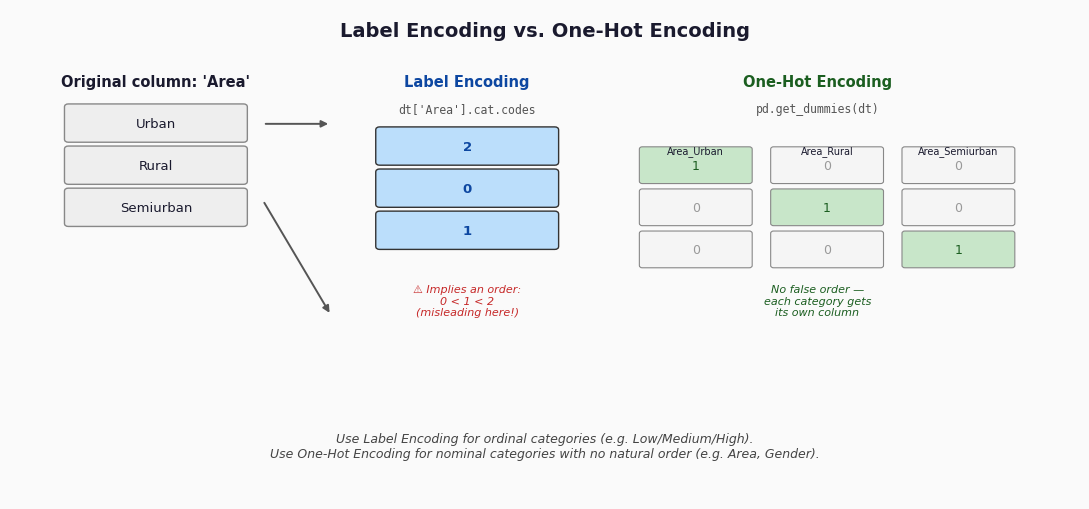

---

### Type 2: One-Hot Encoding (Dummy Variables)

**One-hot encoding** sidesteps the false-ordering problem entirely: instead of one column with integer codes, it creates a **separate binary (0/1) column for each category**. A row gets a `1` in the column matching its category and `0` everywhere else. This is the safer default for **nominal** categories with no inherent order.

In [41]:
# Drop a column using column name (this column has high cardinality, i.e. lots of unique
# categories, and we don't want it one-hot encoded — Loan_ID is unique per row)
df2 = dataset.drop(['Loan_ID'], axis=1)

`Loan_ID` is a unique identifier — every row has a different value. One-hot encoding it would create one column *per applicant*, which is useless for modeling and would blow up the dataset's width. High-cardinality identifier columns like this are almost always dropped before encoding. `axis=1` tells `.drop()` we're removing a **column**, not a row.

In [42]:
df2.head()

,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,NaN,5849.0,0.0,NaN,urban,Y
1,Male,4583.0,NaN,128.0,semi,N
2,Male,3000.0,0.0,66.0,NaN,Y
3,Female,2583.0,2358.0,120.0,semi,NaN
4,Male,NaN,0.0,141.0,urban,Y


In [43]:
# using get_dummies function of Pandas
df2 = pd.get_dummies(df2)

`pd.get_dummies()` automatically finds every remaining text/categorical column and one-hot encodes it — no need to specify columns manually. Numeric columns (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`) are left untouched.

In [44]:
df2.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Gender_Female,Gender_Male,Area_rural,Area_semi,Area_urban,Loan_Status_N,Loan_Status_Y
0,5849.0,0.0,NaN,False,False,False,False,True,False,True
1,4583.0,NaN,128.0,False,True,False,True,False,True,False
2,3000.0,0.0,66.0,False,True,False,False,False,False,True
3,2583.0,2358.0,120.0,True,False,False,True,False,False,False
4,NaN,0.0,141.0,False,True,False,False,True,False,True


Notice the new columns: `Gender_Male`, `Gender_Female`, `Area_Urban`, `Area_Rural`, `Area_Semiurban`, `Loan_Status_Y`, `Loan_Status_N`, and so on — one binary column per category, per original column.

### The Dummy Variable Trap

The **dummy variable trap** happens when one-hot encoding creates **too many** columns for a category, leading to **multicollinearity** — a situation where columns become mathematically redundant because they're perfectly predictable from each other.

**Concrete example:** `Area` has 3 categories: Urban, Rural, Semiurban. If you know a row's `Area_Urban` and `Area_Rural` values, you *automatically* know `Area_Semiurban` too — it must be `1` exactly when the other two are both `0`. That third column carries **zero new information**, yet including it can confuse linear models (like linear or logistic regression) by making their coefficients unstable.

The fix: for a category with **n** possible values, you only need **n − 1** dummy columns. Pandas makes this a one-line change.

In [45]:
# Avoid dummy variable trap using drop_first

#Step1: Creating a copy of the dataset (dropping the high-cardinality Loan_ID as before):
df3 = dataset.drop(['Loan_ID'], axis=1)

#Step2: Encoding with k-1 dummy columns per category via 'drop_first=True'
df3 = pd.get_dummies(df3, drop_first=True)

In [46]:
df3.head()

#compare it with df2 -- you'll see 'Gender_Female', 'Area_Rural' and 'Loan_Status_N' dropped.
#Nothing is lost: if Gender_Male is 0, we already know the applicant is Female.

,ApplicantIncome,CoapplicantIncome,LoanAmount,Gender_Male,Area_semi,Area_urban,Loan_Status_Y
0,5849.0,0.0,NaN,False,False,True,True
1,4583.0,NaN,128.0,True,True,False,False
2,3000.0,0.0,66.0,True,False,False,True
3,2583.0,2358.0,120.0,False,True,False,False
4,NaN,0.0,141.0,True,False,True,True


`drop_first=True` drops the **first** dummy column alphabetically for every encoded category — here that's `Gender_Female`, `Area_Rural`, and `Loan_Status_N`. The dropped category becomes the implicit **baseline**: a row with `Gender_Male = 0` is understood to be Female, without needing its own column.

---

## Section 4: Data Normalization

**Data normalization** rescales numeric columns onto a common, standard range. It's essential because raw features often live on wildly different scales — `ApplicantIncome` might range into the tens of thousands, while `LoanAmount` might only range into the hundreds. Without normalization, algorithms that rely on distances or gradients (like KNN, SVMs, or gradient descent-based models) can end up dominated by whichever column happens to have the largest raw numbers — not the one that's actually most predictive.

We'll scale the three numeric columns: `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount`.

In [47]:
# Extract the numeric columns to scale, by name (safer than position-based iloc,
# since column order in the file could change without this code breaking)
data_to_scale = dataset_clean_full[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]

We're using `dataset_clean_full` here — the fully missing-value-free version from Section 2 — since scalers can't handle `NaN` values.

> 💡 **Why select by name instead of position?** `dataset_clean_full.iloc[:, 2:5]` would also grab these three columns *today* — but if a column were ever inserted or reordered upstream, that position-based slice would silently start pulling the wrong data with no error. Selecting `[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]` by name is more verbose but far more robust.

In [48]:
data_to_scale.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount
5,5417.0,4196.0,267.0
7,3036.0,2504.0,158.0
8,4006.0,1526.0,168.0
9,12841.0,10968.0,349.0
10,3200.0,700.0,70.0


### Type 1: Standard Scaler

**StandardScaler** standardizes each column to have a **mean of 0** and a **standard deviation of 1**, using the formula:

$$z = \frac{x - \text{mean}}{\text{standard deviation}}$$

This is the go-to choice when your data is roughly normally distributed, or when an algorithm (like linear regression, logistic regression, or PCA) assumes standardized inputs.

In [49]:
!pip install scikit-learn

Sometimes, you might encounter an error like **"ModuleNotFoundError: No module named 'sklearn'"**. Running the cell above installs the `scikit-learn` library and avoids this error.

In [50]:
# Import the StandardScaler class
from sklearn.preprocessing import StandardScaler

In [51]:
# Create an object of the class StandardScaler
scaler = StandardScaler()

In [52]:
# Fit and Transform the data for normalization
ss_scaler = scaler.fit_transform(data_to_scale)

`.fit_transform()` does two things in one step: **fit** learns each column's mean and standard deviation from the data, then **transform** applies the standardization formula using those learned values.

In [53]:
ss_scaler

array([[ 0.32879835,  0.43390231,  1.1995349 ],
       [-0.40126276, -0.11198867,  0.05261118],
       [-0.10384182, -0.4275214 ,  0.15783354],
       [ 2.60514177,  2.61875676,  2.06235824],
       [-0.35097716, -0.69401428, -0.87334558],
       [-0.56561083, -0.32621539, -0.46297838],
       [-0.76399367, -0.00358478, -0.4103672 ],
       [-0.9338609 , -0.56947886, -1.43102409],
       [ 0.18560703, -0.9198557 , -0.29462261]])

Notice the result is a plain **NumPy array** — Pandas' column names and index don't survive `scikit-learn`'s transformation. To keep working with it as a labeled DataFrame, we convert it back and reattach the original column names.

In [54]:
# Convert numpy array to pandas DataFrame
df_ss = pd.DataFrame(ss_scaler)

# Use the head() method
print(df_ss.head())     #column names have changed to 0, 1, 2 instead of 'ApplicantIncome', 'CoapplicantIncome' and 'LoanAmount'

          0         1         2
0  0.328798  0.433902  1.199535
1 -0.401263 -0.111989  0.052611
2 -0.103842 -0.427521  0.157834
3  2.605142  2.618757  2.062358
4 -0.350977 -0.694014 -0.873346


In [55]:
# To retain the original column names after converting a numpy array back to a
# pandas DataFrame, pass them in explicitly using the 'columns' parameter:

# Original column names
column_names = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Convert numpy array back into a labeled DataFrame
df_ss = pd.DataFrame(ss_scaler, columns=column_names)
df_ss.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount
0,0.328798,0.433902,1.199535
1,-0.401263,-0.111989,0.052611
2,-0.103842,-0.427521,0.157834
3,2.605142,2.618757,2.062358
4,-0.350977,-0.694014,-0.873346


Now `df_ss` has meaningful column names again, and every value has been rescaled — you should see numbers centered around 0, with roughly equal spread across all three columns, regardless of their original units.

---

### Type 2: Min-Max Scaler

**MinMaxScaler** rescales each column into a fixed range — by default **0 to 1** — using the formula:

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

This is a good choice when you need values in a bounded range (e.g. for neural networks, or algorithms sensitive to the specific scale of inputs), or when your data isn't normally distributed.

In [56]:
# MinMax Normalization of the data
from sklearn.preprocessing import minmax_scale

In [57]:
# Fit and Transform the data for MinMax normalization
mm_scaler = minmax_scale(data_to_scale)

In [58]:
mm_scaler #numpy array, same as before -- every value should now be between 0 and 1

array([[0.35678392, 0.38256747, 0.75301205],
       [0.15049385, 0.22830051, 0.4246988 ],
       [0.23453474, 0.13913202, 0.45481928],
       [1.        , 1.        , 1.        ],
       [0.16470282, 0.06382203, 0.15963855],
       [0.10405476, 0.16776076, 0.27710843],
       [0.04799861, 0.25893508, 0.29216867],
       [0.        , 0.09901532, 0.        ],
       [0.31632299, 0.        , 0.3253012 ]])

In [59]:
# As before, convert the numpy array back into a labeled DataFrame using the
# original column names:

# Original column names
column_names = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Convert numpy array back into a labeled DataFrame
df_mm = pd.DataFrame(mm_scaler, columns=column_names)
df_mm.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount
0,0.356784,0.382567,0.753012
1,0.150494,0.228301,0.424699
2,0.234535,0.139132,0.454819
3,1.000000,1.000000,1.000000
4,0.164703,0.063822,0.159639


### Which Scaler Should You Use?

| | StandardScaler | MinMaxScaler |
|---|---|---|
| Output range | Centered at 0, unbounded (usually roughly −3 to +3) | Fixed range, usually 0 to 1 |
| Best when | Data is roughly normally distributed; algorithm assumes standardized input (linear/logistic regression, PCA, SVM) | You need a bounded range; data isn't normally distributed; neural networks |
| Sensitive to outliers? | Less sensitive | **Very** sensitive — one extreme value stretches the whole range |

There's no universally "correct" choice — it depends on your data's distribution and the model you plan to use.

---

## Section 5: Data Splitting

**Data splitting** divides a dataset into separate parts for **training** and **evaluating** a model. This is one of the most important habits in machine learning: if you test a model on the same data it learned from, you have no way of knowing whether it actually learned general patterns, or just **memorized** the training examples (a problem called overfitting). The most common splits are:

- **Training set** — used to teach the model (typically 70–80% of the data).
- **Test set** — held back entirely during training, then used afterward to check how well the model performs on data it has never seen (typically 20–30%).

In [60]:
df = dataset.copy()

In [61]:
df.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,LP001002,NaN,5849.0,0.0,NaN,urban,Y
1,LP001003,Male,4583.0,NaN,128.0,semi,N
2,LP001005,Male,3000.0,0.0,66.0,NaN,Y
3,LP001006,Female,2583.0,2358.0,120.0,semi,NaN
4,LP001008,Male,NaN,0.0,141.0,urban,Y


### Splitting Columns: Features (X) vs. Target (Y)

Before splitting rows into train/test, we first split **columns** into:

- **X** — the **independent variables** (features) the model will learn from — everything except the last column.
- **Y** — the **dependent variable** (target) the model is trying to predict — here, `Loan_Status`.

In [62]:
# Split by column for X (independent) and Y (dependent) variables
X = df.iloc[:, :-1]
Y = df.iloc[:, [-1]]

**Why is `Y` written with double square brackets `[-1]` instead of just `-1`?**

- `df.iloc[:, -1]` (single brackets) returns a 1-D Pandas **Series** — just the raw values of the last column.
- `df.iloc[:, [-1]]` (double brackets, using a **list** containing `-1`) returns a 2-D **DataFrame** with one column, keeping the column name and structure intact.

Many scikit-learn functions — including `train_test_split` below — are happy to accept either shape for the target, but keeping `Y` as a DataFrame (matching the shape of `X`) makes the code more consistent and makes it easier to inspect `Y.head()` the same way you'd inspect any other DataFrame.

In [63]:
X.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area
0,LP001002,NaN,5849.0,0.0,NaN,urban
1,LP001003,Male,4583.0,NaN,128.0,semi
2,LP001005,Male,3000.0,0.0,66.0,NaN
3,LP001006,Female,2583.0,2358.0,120.0,semi
4,LP001008,Male,NaN,0.0,141.0,urban


In [64]:
Y.head()

,Loan_Status
0,Y
1,N
2,Y
3,NaN
4,Y


In [65]:
df.head()

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area,Loan_Status
0,LP001002,NaN,5849.0,0.0,NaN,urban,Y
1,LP001003,Male,4583.0,NaN,128.0,semi,N
2,LP001005,Male,3000.0,0.0,66.0,NaN,Y
3,LP001006,Female,2583.0,2358.0,120.0,semi,NaN
4,LP001008,Male,NaN,0.0,141.0,urban,Y


### Splitting Rows: Train vs. Test

Now we split by **rows**, so that some applicants go into training and the rest go into testing.

In [66]:
# Split by rows for training and test datasets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test =      \
train_test_split(X, Y, test_size=0.3, random_state=1234)

**Explanation of the parameters:**

- `test_size=0.3` reserves **30%** of the rows for testing, and the remaining **70%** for training.
- `random_state=1234` fixes the random shuffling that happens before splitting — using the same number every time means you (and anyone else running this notebook) get the **exact same split**, making results reproducible. Change it to any other integer and you'll get a different, but equally valid, split.
- The function returns **four** objects in this fixed order: `X_train, X_test, Y_train, Y_test`.

> 💡 **Going further:** For classification problems like this one (predicting `Loan_Status`), if the target classes are imbalanced (e.g. far more approvals than rejections), consider adding `stratify=Y` — this ensures the train and test sets preserve the same approval/rejection ratio as the full dataset.

*Just look at the results below and see that the index values (rows) match between `X_train`/`Y_train` and between `X_test`/`Y_test` — each applicant's features stay correctly paired with their outcome.*

**Total values in dataset = 15**

**70% of 15** = 0.7 × 15 = 10.5 ≈ **11** rows (in `X_train` and `Y_train`)

**30% of 15** = 0.3 × 15 = 4.5 ≈ **4** rows (in `X_test` and `Y_test`)

*(Scikit-learn rounds these split sizes so the two counts add back up to 15.)*

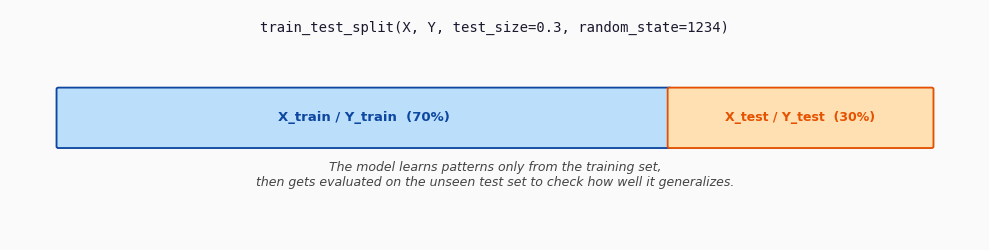

In [68]:
X_train

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area
2,LP001005,Male,3000.0,0.0,66.0,NaN
10,LP001024,Female,3200.0,700.0,70.0,urban
7,LP001014,Female,3036.0,2504.0,158.0,semi
1,LP001003,Male,4583.0,NaN,128.0,semi
9,LP001020,Male,12841.0,10968.0,349.0,semi
8,LP001018,Male,4006.0,1526.0,168.0,rural
4,LP001008,Male,NaN,0.0,141.0,urban
5,LP001011,Male,5417.0,4196.0,267.0,semi
6,LP001013,Male,2333.0,1516.0,NaN,rural
3,LP001006,Female,2583.0,2358.0,120.0,semi


In [69]:
Y_train

,Loan_Status
2,Y
10,Y
7,N
1,N
9,N
8,Y
4,Y
5,Y
6,Y
3,NaN


In [70]:
X_test

,Loan_ID,Gender,ApplicantIncome,CoapplicantIncome,LoanAmount,Area
13,LP001029,Male,1853.0,2840.0,114.0,urban
11,LP001027,Male,2500.0,1840.0,109.0,urban
0,LP001002,NaN,5849.0,0.0,NaN,urban
12,LP001028,Female,NaN,8106.0,NaN,urban
14,LP001030,Male,1299.0,1086.0,17.0,semi


In [71]:
Y_test

,Loan_Status
13,N
11,Y
0,Y
12,Y
14,Y


---

## Summary Cheat Sheet

| Task | Function(s) |
|---|---|
| Load a CSV | `pd.read_csv('file.csv')` |
| Preview data | `.head()`, `.tail()` |
| Select by position | `.iloc[rows, cols]` |
| Select by name | `df[['col1', 'col2']]` |
| Dataset size | `.shape` |
| Column names | `.columns`, `.columns.to_list()` |
| Find missing values | `.isnull()`, `.isnull().sum()` |
| Drop missing rows | `.dropna()`, `.dropna(subset=[...])` |
| Fill missing values | `.fillna(value)` — mode for categories, mean/median for numbers |
| Safe copy | `.copy()` |
| Label Encoding | `.astype('category')` then `.cat.codes` |
| One-Hot Encoding | `pd.get_dummies(df)`, `drop_first=True` to avoid the dummy variable trap |
| Standardize (mean 0, std 1) | `sklearn.preprocessing.StandardScaler` |
| Scale to [0, 1] | `sklearn.preprocessing.minmax_scale` |
| Split features/target | `X = df.iloc[:, :-1]`, `Y = df.iloc[:, [-1]]` |
| Split train/test | `sklearn.model_selection.train_test_split` |

---

